# 調和回帰による補間（提供コード版）

このノートブックでは、補間部を次の3関数ベースで整理しています。

- `build_design_matrix`
- `fit_window_harmonic`
- `predict_harmonic_on_grid`

流れは次の通りです。

1. 観測角度から設計行列を作る
2. 最小二乗で係数 `beta` を求める
3. 等間隔グリッド上で予測波形を作る


In [1]:
import numpy as np
import matplotlib.pyplot as plt


def build_design_matrix(theta_deg: np.ndarray, K: int = 3) -> np.ndarray:
    """角度[deg]から調和回帰の設計行列を作る。"""
    theta_deg = np.asarray(theta_deg, dtype=float).reshape(-1)

    # 度 -> ラジアン
    theta_rad = 2.0 * np.pi * theta_deg / 360.0

    # 定数項（平均の高さ）
    cols = [np.ones_like(theta_rad)]

    # cos, sin の成分を順番に追加
    for k in range(1, K + 1):
        cols.append(np.cos(k * theta_rad))
        cols.append(np.sin(k * theta_rad))

    # 横に並べて行列にする
    return np.column_stack(cols)


def fit_window_harmonic(theta_deg: np.ndarray, y: np.ndarray, K: int = 3) -> np.ndarray:
    """観測点に対して最小二乗で係数 beta を求める。"""
    theta_deg = np.asarray(theta_deg, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)

    if len(theta_deg) != len(y):
        raise ValueError('theta_deg と y の長さが一致していません。')
    if len(theta_deg) == 0:
        raise ValueError('入力が空です。')

    valid = np.isfinite(theta_deg) & np.isfinite(y)
    theta_deg = np.mod(theta_deg[valid], 360.0)
    y = y[valid]

    if len(theta_deg) == 0:
        raise ValueError('有効な観測データがありません。')

    # 角度から説明行列 X を作る
    X = build_design_matrix(theta_deg, K=K)

    # X @ beta ≈ y となる beta を最小二乗で求める
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)

    # 求まった係数を返す
    return beta


def predict_harmonic_on_grid(beta: np.ndarray, L: int = 256, K: int = 3):
    """求めた係数 beta を使って、等間隔グリッド上の補間波形を作る。"""
    beta = np.asarray(beta, dtype=float).reshape(-1)

    # 0〜360度未満の等間隔グリッドを作る
    grid_deg = np.arange(L) * 360.0 / L

    # その角度に対する説明行列を作る
    Xg = build_design_matrix(grid_deg, K=K)

    # 予測波形を計算
    y_grid = Xg @ beta
    return grid_deg, y_grid


def harmonic_interpolation(theta_deg_obs: np.ndarray, y_obs: np.ndarray, L: int = 256, K: int = 3):
    """1周期の不等間隔観測点から、等間隔グリッドの補間波形を返す。"""
    beta = fit_window_harmonic(theta_deg_obs, y_obs, K=K)
    grid_deg, y_grid = predict_harmonic_on_grid(beta, L=L, K=K)
    return grid_deg, y_grid, beta


beta shape: (11,)
beta =
[ 0.17065875  0.68158863 -0.29118018 -0.39435378  0.36321467 -0.17925672
  0.133785   -0.09260182  0.07150248 -0.060575   -0.03324793]


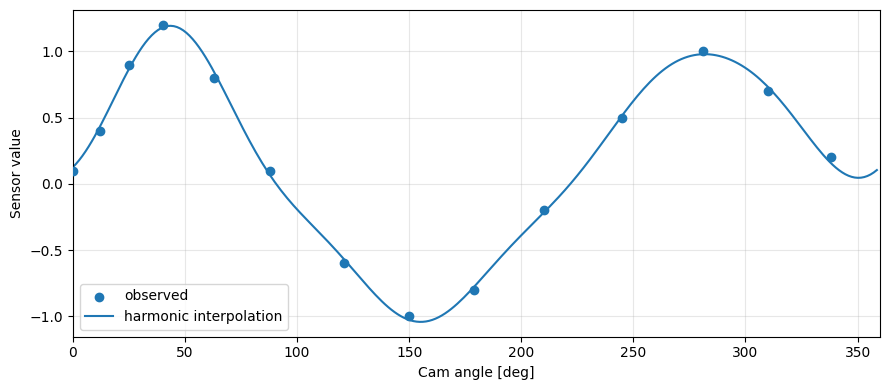

In [2]:
# 例1: シンプルな不等間隔観測点から補間する

theta_deg_obs = np.array([0, 12, 25, 40, 63, 88, 121, 150, 179, 210, 245, 281, 310, 338], dtype=float)
y_obs = np.array([0.1, 0.4, 0.9, 1.2, 0.8, 0.1, -0.6, -1.0, -0.8, -0.2, 0.5, 1.0, 0.7, 0.2], dtype=float)

K = 5
L = 256

grid_deg, y_grid, beta = harmonic_interpolation(theta_deg_obs, y_obs, L=L, K=K)

print('beta shape:', beta.shape)
print('beta =')
print(beta)

plt.figure(figsize=(9, 4))
plt.scatter(theta_deg_obs, y_obs, label='observed', zorder=3)
plt.plot(grid_deg, y_grid, label='harmonic interpolation')
plt.xlim(0, 360)
plt.xlabel('Cam angle [deg]')
plt.ylabel('Sensor value')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


RMSE vs clean reference: 0.0275


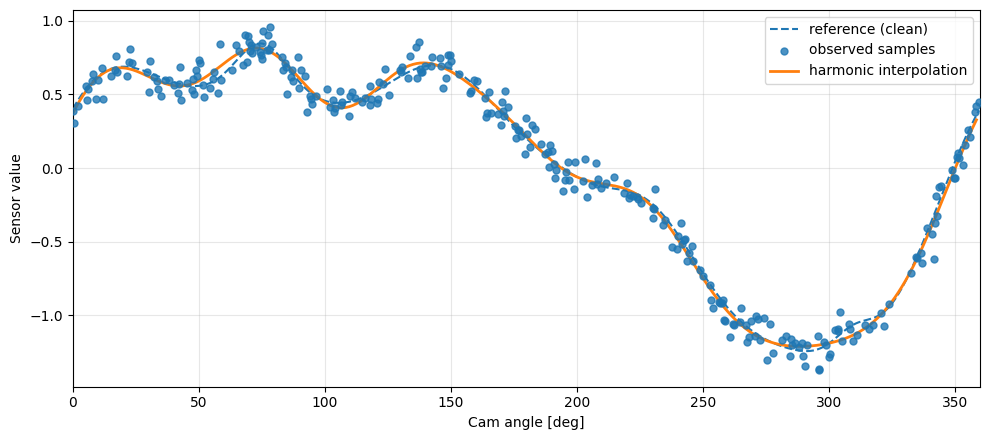

In [3]:
# 例2: 少し複雑な基準波形から不等間隔サンプリングして補間する

rng = np.random.default_rng(42)

n_base = 1000
deg_base = np.linspace(0.0, 360.0, n_base, endpoint=False)
theta = np.deg2rad(deg_base)

# 複雑さを持たせた基準波形
# 基本波 + 高調波 + 局所的な盛り上がり

def circular_gaussian(deg, center_deg, sigma_deg):
    d = np.abs((deg - center_deg + 180.0) % 360.0 - 180.0)
    return np.exp(-0.5 * (d / sigma_deg) ** 2)


y_base_clean = (
    0.85 * np.sin(theta - 0.2)
    + 0.40 * np.sin(2 * theta + 0.9)
    + 0.18 * np.cos(3 * theta - 0.4)
    + 0.10 * np.sin(5 * theta + 1.2)
    + 0.30 * circular_gaussian(deg_base, 75.0, 10.0)
    - 0.22 * circular_gaussian(deg_base, 210.0, 14.0)
    + 0.16 * circular_gaussian(deg_base, 310.0, 8.0)
)

y_base = y_base_clean + 0.05 * rng.standard_normal(n_base)

# 不等間隔サンプリング
n_obs = 300
obs_idx = np.sort(rng.choice(n_base, size=n_obs, replace=False))
theta_deg_obs = deg_base[obs_idx]
y_obs = y_base[obs_idx] + 0.05 * rng.standard_normal(n_obs)

# 補間
K = 8
L = 256
grid_deg, y_grid, beta = harmonic_interpolation(theta_deg_obs, y_obs, L=L, K=K)

# 基準波形を同じグリッドに出す（比較用）
deg_base_closed = np.r_[deg_base, 360.0]
y_base_closed = np.r_[y_base_clean, y_base_clean[0]]
y_ref = np.interp(grid_deg, deg_base_closed, y_base_closed)

rmse = np.sqrt(np.mean((y_grid - y_ref) ** 2))
print(f'RMSE vs clean reference: {rmse:.4f}')

plt.figure(figsize=(10, 4.5))
plt.plot(deg_base, y_base_clean, '--', label='reference (clean)')
plt.scatter(theta_deg_obs, y_obs, s=25, alpha=0.8, label='observed samples', zorder=3)
plt.plot(grid_deg, y_grid, linewidth=2, label='harmonic interpolation')
plt.xlim(0, 360)
plt.xlabel('Cam angle [deg]')
plt.ylabel('Sensor value')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 対応する式

このノートブックのコードは、次の形の調和回帰を使っています。

$$
\hat y(\theta_{\mathrm{deg}})
=
\beta_0
+
\sum_{k=1}^{K}
\left[
\beta_{2k-1}\cos\left(k\frac{2\pi}{360}\theta_{\mathrm{deg}}\right)
+
\beta_{2k}\sin\left(k\frac{2\pi}{360}\theta_{\mathrm{deg}}\right)
\right]
$$

`fit_window_harmonic` は係数 `beta` を求める部分、
`predict_harmonic_on_grid` は求めた `beta` を等間隔グリッドで評価する部分です。
